In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import xgboost as xgb


### Model train : K Mean + XGBoost

In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, silhouette_score
from sklearn.cluster import KMeans
import xgboost as xgb

# -----------------------------
# Step 1. Load and prepare data
# -----------------------------
df = pd.read_csv("../database/Modified_Cruise_Preferences_Dataset.csv")

# Standardize all features except destination
features = df.drop(columns=["destination"])
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# -----------------------------
# Step 2. Automatically select the best number of clusters K
# -----------------------------
silhouette_scores = {}
for k in range(2, 11):
    kmeans_temp = KMeans(n_clusters=k, random_state=42)
    labels_temp = kmeans_temp.fit_predict(features_scaled)
    score = silhouette_score(features_scaled, labels_temp)
    silhouette_scores[k] = score
best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"The best number of clusters automatically selected K = {best_k}")

# Use the optimal K value to train the KMeans model and get the cluster labels
kmeans = KMeans(n_clusters=best_k, random_state=42)
df["cluster"] = kmeans.fit_predict(features_scaled)

# Save data containing cluster labels
df.to_csv("../database/Modified_Cruise_Preferences_Dataset_with_clusters.csv", index=False)
print("Save the data with cluster labels to 'Modified_Cruise_Preferences_Dataset_with_clusters.csv'")

# -----------------------------
# Step 3. Train the XGBoost model in each cluster to predict the destination
# -----------------------------
cluster_models = {}   # Save the model and corresponding LabelEncoder of each cluster
cluster_results = []  # Store the prediction results of each cluster

for cluster in df["cluster"].unique():
    print(f"\nProcessing cluster {cluster} ...")
    df_cluster = df[df["cluster"] == cluster].copy()

    # Remove destination classes that appear only once
    value_counts = df_cluster["destination"].value_counts()
    valid_classes = value_counts[value_counts > 1].index
    df_cluster = df_cluster[df_cluster["destination"].isin(valid_classes)]

    # Skip the cluster if too few samples or insufficient number of destination classes
    if df_cluster.shape[0] < 3 or df_cluster["destination"].nunique() < 2:
        print(f"Cluster {cluster} too few valid samples, skip")
        continue

    # Feature X: Use all fields except destination (including cluster itself)
    X = df_cluster.drop(columns=["destination"])
    y = df_cluster["destination"]

    # Convert y into continuous integer labels using LabelEncoder
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    # Split the training and testing sets, with stratification
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded,
        test_size=0.4,
        random_state=42,
        stratify=y_encoded
    )

    # Train the XGBoost model
    model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
    model.fit(X_train, y_train)
    cluster_models[cluster] = (model, label_encoder)

    # Predict on the test set
    y_pred = model.predict(X_test)
    # Convert both predictions and true labels back to the original destination labels
    y_pred_original = label_encoder.inverse_transform(y_pred)
    y_test_original = label_encoder.inverse_transform(y_test)
    print(f"Cluster {cluster} prediction effect")
    print(classification_report(y_test_original, y_pred_original))

    # Store the prediction results in a new column of df_cluster
    df_cluster.loc[X_test.index, "predicted_destination"] = y_pred_original
    cluster_results.append(df_cluster)

# Merge the prediction data of all clusters and save them
df_predictions = pd.concat(cluster_results)
df_predictions.to_csv("../database/XGBoost_Predicted_Destination.csv", index=False)
print("Save the XGBoost prediction results as 'XGBoost_Predicted_Destination.csv'")


The best number of clusters automatically selected K = 4
Save the data with cluster labels to 'Modified_Cruise_Preferences_Dataset_with_clusters.csv'

Processing cluster 0 ...


c:\Users\huang\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [15:54:42] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Cluster 0 prediction effect
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         2
           6       0.00      0.00      0.00         4
           7       0.36      0.39      0.37        90
           8       0.27      0.32      0.29        66
           9       0.40      0.38      0.39        81
          10       0.24      0.24      0.24        59

    accuracy                           0.32       311
   macro avg       0.14      0.15      0.14       311
weighted avg       0.31      0.32      0.32       311


Processing cluster 3 ...


c:\Users\huang\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\huang\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\huang\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\huang\anaconda3\lib\site-packages\xgboost\core

Cluster 3 prediction effect
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           2       1.00      0.50      0.67         2
           3       0.00      0.00      0.00         1
           4       0.53      0.57      0.55        77
           5       0.51      0.46      0.49        56
           6       0.58      0.59      0.58        90

    accuracy                           0.55       227
   macro avg       0.44      0.35      0.38       227
weighted avg       0.54      0.55      0.54       227


Processing cluster 2 ...


c:\Users\huang\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\huang\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\huang\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\huang\anaconda3\lib\site-packages\xgboost\core

Cluster 2 prediction effect
              precision    recall  f1-score   support

           1       0.57      0.55      0.56        91
           2       0.53      0.58      0.55        86
           3       0.00      0.00      0.00         1
           4       1.00      0.33      0.50         3
           5       0.00      0.00      0.00         2
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         2
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00         1

    accuracy                           0.53       191
   macro avg       0.21      0.15      0.16       191
weighted avg       0.52      0.53      0.52       191


Processing cluster 1 ...


c:\Users\huang\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\huang\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\huang\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\huang\anaconda3\lib\site-packages\xgboost\core

Cluster 1 prediction effect
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.93      1.00      0.96        66
           4       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         1

    accuracy                           0.93        71
   macro avg       0.19      0.20      0.19        71
weighted avg       0.86      0.93      0.90        71

Save the XGBoost prediction results as 'XGBoost_Predicted_Destination.csv'


c:\Users\huang\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\huang\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\huang\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### visualization

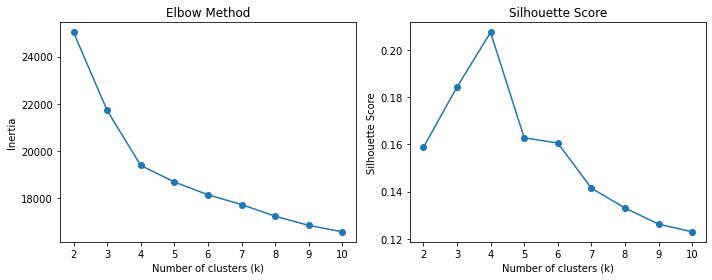

In [ ]:
# Draw a line chart of K value and Inertia/Silhouette Score
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

K_range = range(2, 11)
inertia_values = []
silhouette_scores_values = []

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(features_scaled)
    inertia_values.append(kmeans_temp.inertia_)
    silhouette_scores_values.append(silhouette_score(features_scaled, kmeans_temp.labels_))


plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertia_values, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores_values, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()


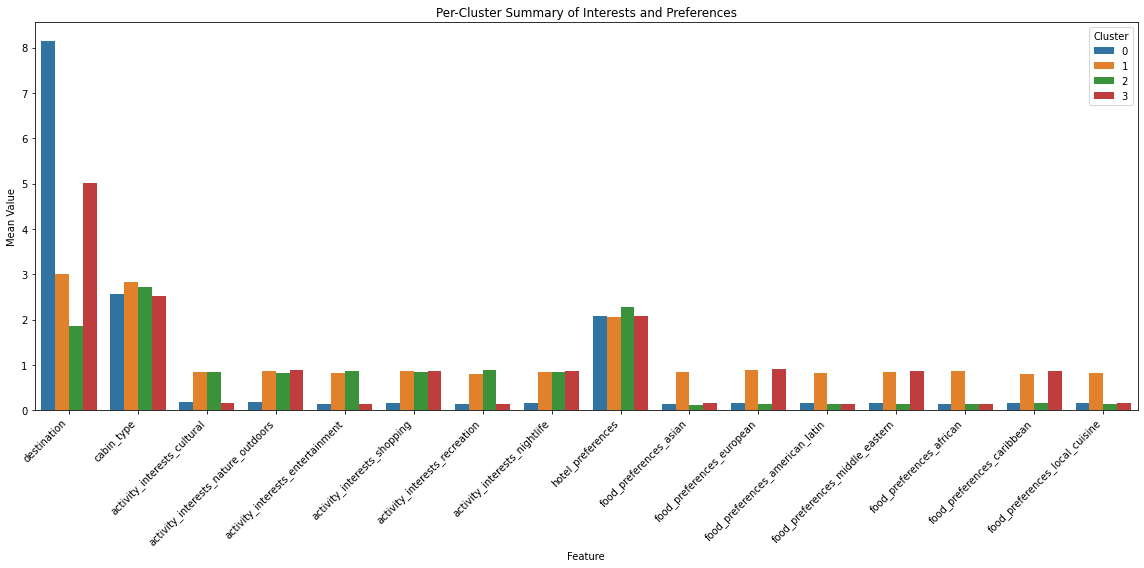

In [28]:
#  Draw a histogram based on the mean value of each cluster
import seaborn as sns

# Calculate the mean of each numeric feature for each cluster
cluster_summary = df.groupby('cluster').mean(numeric_only=True)

# Reshape the data for plotting
melted_summary = cluster_summary.reset_index().melt(id_vars='cluster',
var_name='Feature',
value_name='Mean Value')

# Convert the cluster column to a string (for legend display)
melted_summary['cluster'] = melted_summary['cluster'].astype(str)

# Use seaborn to plot a bar plot of the mean values ​​for each cluster
plt.figure(figsize=(16, 8))
sns.barplot(data=melted_summary, x='Feature', y='Mean Value', hue='cluster')

plt.title('Per-Cluster Summary of Interests and Preferences')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

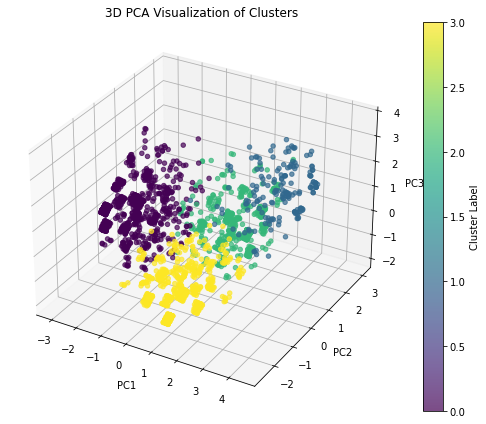

In [29]:
# 3D visualization after dimensionality reduction using PCA
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D # Although the module is imported, you can directly call projection='3d' in matplotlib

# Use PCA to reduce the dimension to 3
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(features_scaled)

# Get cluster labels from df
cluster_labels = df['cluster'].values

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
 c=cluster_labels, cmap='viridis', alpha=0.7)

ax.set_title('3D PCA Visualization of Clusters')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

plt.colorbar(scatter, ax=ax, label='Cluster Label')
plt.tight_layout()
plt.show()

### destination prediction (using K mean and XGBoost)

In [25]:
# -----------------------------
new_samples = pd.read_csv("../database/Simulated_20_New_Samples_For_Testing.csv")
# -----------------------------
# Step 2: Standardize the new sample data and predict the cluster
# -----------------------------
X_new = new_samples.drop(columns=["destination"])
# Use the same scaler as used during training for normalization
X_new_scaled = scaler.transform(X_new)
# Predict the cluster of new samples (standardized data is used for model training)
predicted_clusters = kmeans.predict(X_new_scaled)
# Add the predicted cluster to the new sample data, consistent with the training
new_samples["cluster"] = predicted_clusters

# -----------------------------
# Step 3: Use the XGBoost model of the corresponding cluster to predict the destination
# -----------------------------
predicted_destinations = []

for i, row in new_samples.iterrows():
    cluster = row["cluster"]
    if cluster not in cluster_models:
        predicted_destinations.append("Unknown")
        continue

    model, label_encoder = cluster_models[cluster]
    row_features = row.drop("destination") 
    row_df = pd.DataFrame([row_features])
    
    # Predict the encoded target label
    y_encoded = model.predict(row_df)[0]
    # Convert the prediction results back to the original destination label
    y_label = label_encoder.inverse_transform([y_encoded])[0]
    predicted_destinations.append(y_label)

# Write the prediction results back to the new sample DataFrame
new_samples["predicted_destination"] = predicted_destinations

# -----------------------------
# Step 4: Save the prediction results
# -----------------------------
new_samples.to_csv("../database/Simulated_20_New_Samples_With_Predictions.csv", index=False)
print("Prediction completed, results saved in 'Simulated_20_New_Samples_With_Predictions.csv'")


Prediction completed, results saved in 'Simulated_20_New_Samples_With_Predictions.csv'


### preference prediction (using K mean and Randomforest)

In [26]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Step 1: Load the dataset with pre-computed cluster labels
df = pd.read_csv("../database/Modified_Cruise_Preferences_Dataset_with_clusters.csv")

# We are interested in predicting the user's activity, so we define activity-related columns
activity_cols = [
    'activity_interests_cultural', 
    'activity_interests_nature_outdoors',
    'activity_interests_entertainment', 
    'activity_interests_shopping',
    'activity_interests_recreation', 
    'activity_interests_nightlife'
]

# Step 2: Calculate P(cluster | destination) based on the existing "cluster" column
dest_cluster_probs = pd.crosstab(df['destination'], df['cluster'], normalize='index')

# Step 3: Train a model for each cluster and activity (using destination and cluster as features)
models = {}

clusters = sorted(df['cluster'].unique())
for cluster in clusters:
    cluster_df = df[df['cluster'] == cluster]
    # Use the "destination" and "cluster" features when training the model
    X = cluster_df[['destination', 'cluster']]
    for activity in activity_cols:
        y = cluster_df[activity]
        clf = RandomForestClassifier(random_state=42)
        clf.fit(X, y)
        models[(cluster, activity)] = clf

# Step 4: Helper function for safe prediction of positive probability
def safe_predict_proba(clf, x_input):
    proba = clf.predict_proba([x_input])[0]
    if len(proba) == 2:
        return proba[1]
    return 0.0 if clf.classes_[0] == 1 else 1.0

# Step 5: Weighted prediction function: given a destination value, predict the probability of each activity
def predict_activities_weighted(dest_val):
    preds = {}
    for activity in activity_cols:
        weighted_sum = 0.0
        # Calculate weights for each cluster: P(cluster|destination) * model prediction probability
        for cluster in clusters:
            # If the destination does not exist in the training data, set the weight to 0
            if dest_val in dest_cluster_probs.index:
                prob_cluster_given_dest = dest_cluster_probs.loc[dest_val, cluster]
            else:
                prob_cluster_given_dest = 0.0

            clf = models[(cluster, activity)]
            x_input = [dest_val, cluster]
            pred_prob = safe_predict_proba(clf, x_input)
            weighted_sum += prob_cluster_given_dest * pred_prob
        preds[activity] = weighted_sum
    return preds

# Step 6: Create a DataFrame for destination 1-10, showing prediction probability for each activity
results = []
for dest in range(1, 11):
    preds = predict_activities_weighted(dest)
    preds['destination'] = dest
    results.append(preds)

results_df = pd.DataFrame(results)
results_df = results_df.set_index('destination')
print("Prediction results for each destination (1-10):")
print(results_df)

# Optionally save the table to a CSV file
results_df.to_csv("../database/Destination_Activity_Predictions.csv")
print("The result table is saved as 'Destination_Activity_Predictions.csv'")



Prediction results for each destination (1-10):
             activity_interests_cultural  activity_interests_nature_outdoors  \
destination                                                                    
1                               0.824247                            0.820432   
2                               0.867674                            0.856490   
3                               0.853251                            0.886035   
4                               0.141200                            0.848786   
5                               0.219461                            0.870608   
6                               0.140469                            0.898107   
7                               0.169968                            0.146478   
8                               0.200967                            0.226621   
9                               0.151621                            0.174181   
10                              0.190900                            0.13